In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import ParameterGrid

import sys
from itertools import product
sys.path.append('../../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt
import src.fda.dfpc              as dfpc

In [2]:
from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA

In [6]:
# Define scenarios
gas_params = {
    # "scenario_1": {
    #     "Description": "Location-driven ($m_t$)",
    #     "alpha": np.diag([0.08, 0.01, 0.01]),
    #     "beta": np.diag([0.90, 0.95, 0.95]),
    # },
    # "scenario_2": {
    #     "Description": "Scale-driven ($\sigma_t$)",
    #     "alpha": np.diag([0.01, 0.08, 0.01]),
    #     "beta": np.diag([0.95, 0.90, 0.95]),
    # },
    # "scenario_3": {
    #     "Description": "Shape-driven ($\eta_t$)",
    #      "alpha": np.diag([0.01, 0.01, 0.08]),
    #       "beta": np.diag([0.95, 0.95, 0.90])
    # },
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3]
}

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})
    
# grid for densities
x = np.linspace(-40, 40, 5001)
# number of curves (densities)
T = 301
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 10
# number of samples from each f_t density
N_SAMPLES = 288

total = len(param_grid) * N_REPS

sim_database = {}
total = len(param_grid) * N_REPS

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

returns_df = sim_database['scenario_4___nu=3']['replications'][0]['samples']
# bandwidths
kde_bw_params = {"method": "rot", "kernel": "gaussian", "sigma_robust":False}

df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params)    
kde_params = {k: v for k, v in kde_bw_params.items() if k in ['kernel', 'df']}

# kdes
df_grids, df_densities = kde.df_to_kde(
    X=returns_df, 
    h=df_h, 
    normalize_densities=False,
    **kde_params
)

<Axes: >

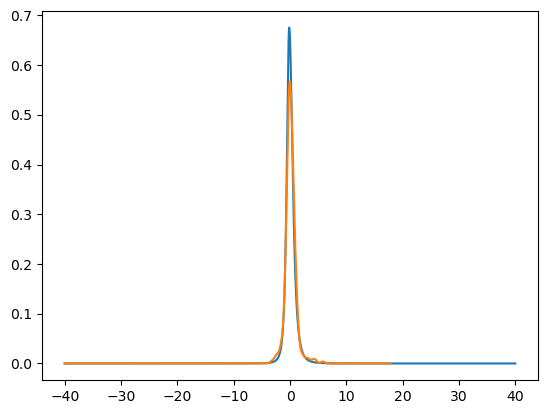

In [7]:
i = 100
sim_database['scenario_4___nu=3']['replications'][0]["densities"].iloc[:,i].plot(legend=False)
df_densities.iloc[:,i].plot(legend=False)

In [8]:
mlqdt = lqdt.mLQDT()
model_lqd = mlqdt.transform(
    densities=df_densities,
    densities_supports=df_grids, 
    verbose=False
    )
# model_lqd.densities_to_lqdensities(verbose=False)

# 2. L2 Expansion (K_dFPC)
Y_t  = model_lqd.lqd.copy()
Y_t.index = model_lqd.lqd_support

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [9]:
Y_t

,2025-08-08,2025-08-09,2025-08-10,2025-08-11,2025-08-12,2025-08-13,2025-08-14,2025-08-15,2025-08-16,2025-08-17,...,2026-05-26,2026-05-27,2026-05-28,2026-05-29,2026-05-30,2026-05-31,2026-06-01,2026-06-02,2026-06-03,2026-06-04
0.0000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
0.0002,6.875063,6.984486,6.753473,6.670011,6.868575,6.696780,6.793401,6.859631,6.881633,6.821994,...,6.550324,6.734977,6.980489,6.862143,6.519202,7.015347,6.718093,6.818053,6.614634,6.450260
0.0004,6.353664,6.462904,6.231900,6.106924,6.346707,6.173572,6.271940,6.337844,6.356460,6.261162,...,6.028402,6.213385,6.458859,6.340664,5.917341,6.493961,6.196349,6.296443,6.092551,5.896290
0.0006,6.078983,6.188490,5.957550,5.794133,6.072357,5.896198,5.997380,6.063484,6.076595,5.950373,...,5.753644,5.938915,6.184472,6.066110,5.572388,6.219441,5.921931,6.021929,5.818154,5.588685
0.0008,5.906093,6.015657,5.784639,5.582670,5.899499,5.719031,5.824485,5.890598,5.896632,5.740871,...,5.580772,5.766015,6.011607,5.893308,5.332235,6.046577,5.748984,5.849267,5.645048,5.380175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.9992,5.560659,6.015601,5.783164,5.831114,5.632743,5.366392,5.407981,5.876716,5.698142,5.951067,...,5.579749,5.527783,6.009784,5.889888,5.826502,6.046613,5.747643,5.849267,5.645176,5.532548
0.9994,5.786267,6.188442,5.956733,6.004079,5.859300,5.596039,5.644318,6.055166,5.907901,6.123968,...,5.753281,5.738389,6.183598,6.064286,5.999528,6.219465,5.921024,6.021930,5.818042,5.705576
0.9996,6.114298,6.463010,6.231740,6.278624,6.186379,5.927785,5.983979,6.333345,6.218921,6.398474,...,6.028323,6.050560,6.458492,6.339688,6.274038,6.493951,6.196221,6.296441,6.092705,5.980183
0.9998,6.694663,6.984671,6.753523,6.800147,6.762919,6.513069,6.578703,6.857931,6.779840,6.920167,...,6.550379,6.612557,6.980340,6.861990,6.795465,7.015472,6.717855,6.818054,6.614634,6.501409


In [11]:
model_lqd.lqd

,2025-08-08,2025-08-09,2025-08-10,2025-08-11,2025-08-12,2025-08-13,2025-08-14,2025-08-15,2025-08-16,2025-08-17,...,2026-05-26,2026-05-27,2026-05-28,2026-05-29,2026-05-30,2026-05-31,2026-06-01,2026-06-02,2026-06-03,2026-06-04
0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
1,6.875063,6.984486,6.753473,6.670011,6.868575,6.696780,6.793401,6.859631,6.881633,6.821994,...,6.550324,6.734977,6.980489,6.862143,6.519202,7.015347,6.718093,6.818053,6.614634,6.450260
2,6.353664,6.462904,6.231900,6.106924,6.346707,6.173572,6.271940,6.337844,6.356460,6.261162,...,6.028402,6.213385,6.458859,6.340664,5.917341,6.493961,6.196349,6.296443,6.092551,5.896290
3,6.078983,6.188490,5.957550,5.794133,6.072357,5.896198,5.997380,6.063484,6.076595,5.950373,...,5.753644,5.938915,6.184472,6.066110,5.572388,6.219441,5.921931,6.021929,5.818154,5.588685
4,5.906093,6.015657,5.784639,5.582670,5.899499,5.719031,5.824485,5.890598,5.896632,5.740871,...,5.580772,5.766015,6.011607,5.893308,5.332235,6.046577,5.748984,5.849267,5.645048,5.380175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,5.560659,6.015601,5.783164,5.831114,5.632743,5.366392,5.407981,5.876716,5.698142,5.951067,...,5.579749,5.527783,6.009784,5.889888,5.826502,6.046613,5.747643,5.849267,5.645176,5.532548
4997,5.786267,6.188442,5.956733,6.004079,5.859300,5.596039,5.644318,6.055166,5.907901,6.123968,...,5.753281,5.738389,6.183598,6.064286,5.999528,6.219465,5.921024,6.021930,5.818042,5.705576
4998,6.114298,6.463010,6.231740,6.278624,6.186379,5.927785,5.983979,6.333345,6.218921,6.398474,...,6.028323,6.050560,6.458492,6.339688,6.274038,6.493951,6.196221,6.296441,6.092705,5.980183
4999,6.694663,6.984671,6.753523,6.800147,6.762919,6.513069,6.578703,6.857931,6.779840,6.920167,...,6.550379,6.612557,6.980340,6.861990,6.795465,7.015472,6.717855,6.818054,6.614634,6.501409


In [61]:
fd = FDataGrid(
    data_matrix=model_lqd.lqd.values.T, 
    grid_points=model_lqd.lqd_support
)

In [62]:
model_sfpc = FPCA(n_components=3)

In [63]:
model_sfpc.fit(fd)

,n_components,3
,centering,True
,regularization,None
,components_basis,None
,_weights,"array([6.6666...shape=(5001,))"


In [64]:
def eigenfunctions_to_df(eigenfunctions):
    """
    Convert scikit-fda FPCA eigenfunctions to a DataFrame.

    Parameters
    ----------
    eigenfunctions : FDataGrid
        model_kdfpc.components_

    Returns
    -------
    pd.DataFrame
        Index = grid points
        Columns = eigenfunction_1, eigenfunction_2, ...
    """
    
    grid_points = eigenfunctions.grid_points[0]

    values = eigenfunctions.data_matrix[:, :, 0].T

    return pd.DataFrame(
        values,
        index=grid_points,
        columns=[
            f"eigenfunction_{i+1}"
            for i in range(values.shape[1])
        ]
    )

<Axes: >

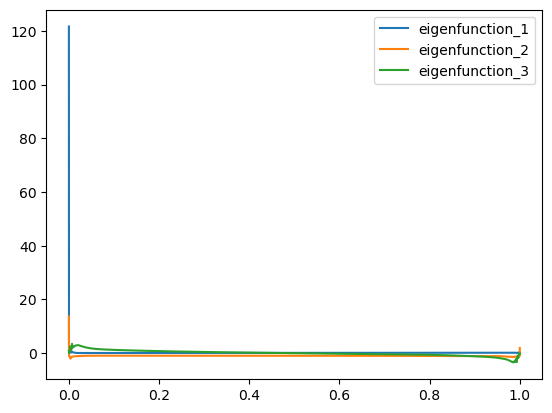

In [65]:
eigenfunctions_df = eigenfunctions_to_df(model_sfpc.components_)
eigenfunctions_df.plot()

In [66]:
scores = model_sfpc.transform(fd)
df_scores_sfpca = pd.DataFrame(scores).add_prefix("score_")

In [67]:
KdFPC_kwargs = {
    "p": 5,
    "dimension": 3
}

lqd_values  = Y_t.values
lqd_support = Y_t.index.values

KdFPC_kwargs.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_kdfpc = dfpc.K_dFPC(lqd_values)
model_kdfpc.fit(**KdFPC_kwargs)

df_scores_dfpca = model_kdfpc.etahat

<Axes: title={'center': 'sFPC'}>

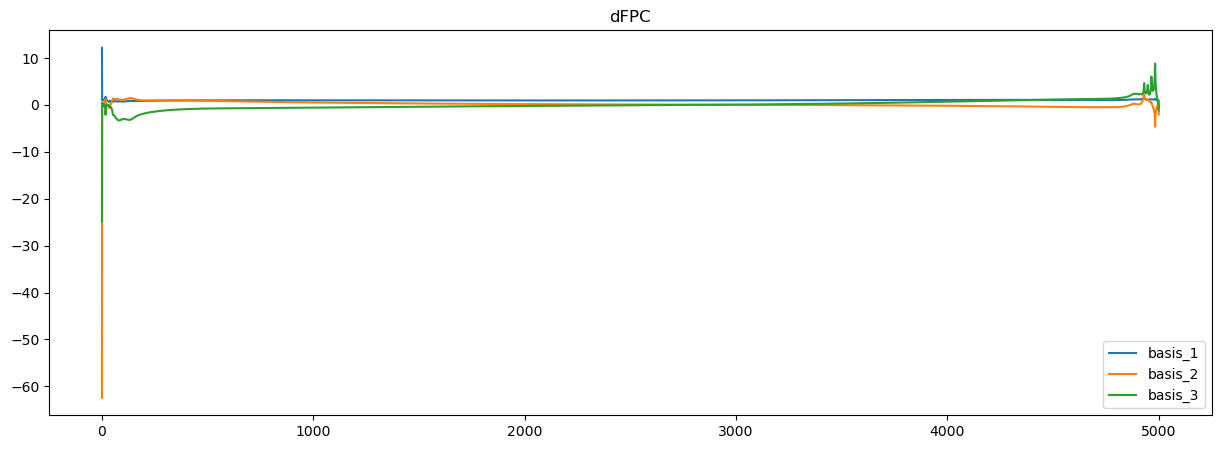

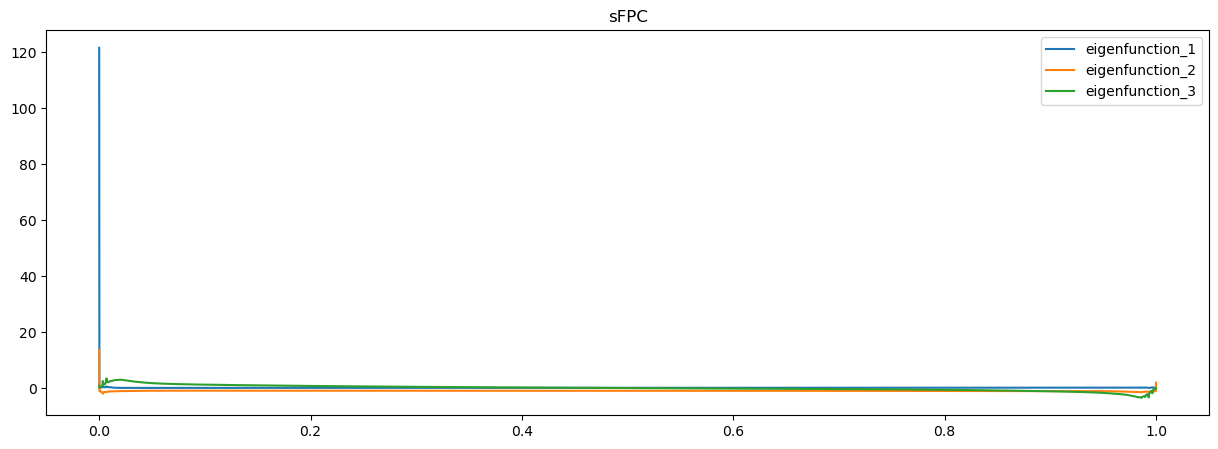

In [69]:
model_kdfpc.psihat.plot(title = "dFPC", figsize=(15,5))
eigenfunctions_df.plot(title = "sFPC", figsize=(15,5))

<Axes: title={'center': 'dFPCA'}>

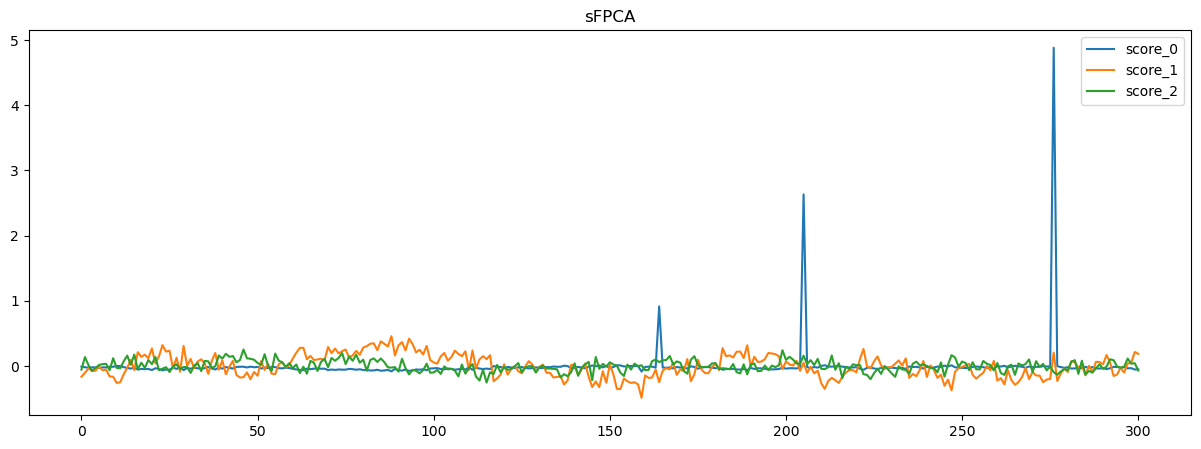

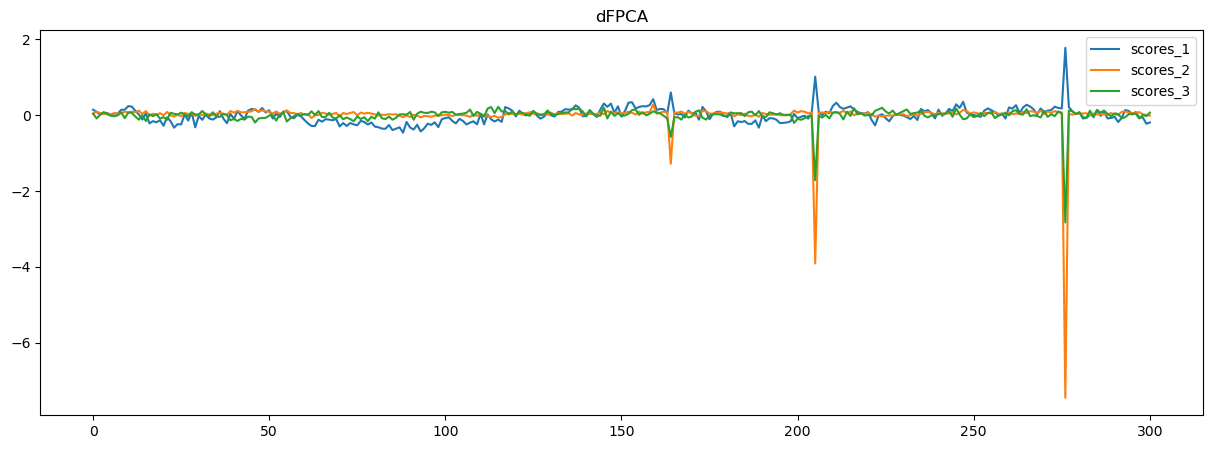

In [43]:
df_scores_sfpca.plot(title="sFPCA", figsize=(15,5))
df_scores_dfpca.plot(title="dFPCA", figsize=(15,5))

# Implementação de classe

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skfda import FDataGrid
from skfda.preprocessing.dim_reduction import FPCA

class sFPC:
    """
    Implements a Static Functional Principal Component Analysis (sFPC) wrapper 
    using skfda. Designed as a drop-in replacement for the K_dFPC class.

    This class takes as input a matrix Y of shape (m, T), where:
        m = number of grid points
        T = number of time points (curves)
    """

    def __init__(self, Y):
        """
        Initialize the model with data.

        Parameters
        ----------
        Y : ndarray (m, T)
            Functional time series sample evaluated on an m-point grid.
        """
        # skfda requires a copy if we are modifying it, but we'll modify in fit
        self.Y = np.copy(Y) if isinstance(Y, np.ndarray) else Y.values.copy()
        self.m, self.T = self.Y.shape

        # Filled after fit()
        self.Ybar = None
        self.thetahat = None
        self.gammahat = None  # Will remain None (not applicable for static FPC)
        self.psihat = None
        self.etahat = None
        self.Yhat = None
        self.epsilonhat = None
        self.d0 = None
        self.u = None
        self.bs_pvalues = None
        self.fitted_values = None
        self.cumvar = None
        self.model = None

    def fit(self, p=None, u=None, du=0.05, lag_max=5, B=1_000, alpha=0.05, 
            select_ncomp=False, dimension=None):
        """
        Fit the static FPC model using skfda.

        Note: Dynamic parameters (p, lag_max, B, alpha) are accepted in the 
        signature to maintain pipeline compatibility but are ignored during fitting.
        """
        self.u = u if u is not None else np.arange(self.m)

        # Substitutes INF values (matching your original preprocessing)
        if np.isinf(self.Y).any():
            self.Y[np.isinf(self.Y)] = 1000

        # 1. Prepare data for skfda
        # Y is (m, T). skfda expects (n_samples, n_features), which is (T, m).
        fd = FDataGrid(data_matrix=self.Y.T, grid_points=self.u)

        # 2. Component Selection
        if select_ncomp == "variance":
            # Fit a temporary model to determine cumulative variance
            temp_model = FPCA(n_components=min(self.m, self.T) - 1)
            temp_model.fit(fd)
            cumvar = np.cumsum(temp_model.explained_variance_ratio_)
            d0 = np.argmax(cumvar >= 0.95) + 1
            if d0 == 1:
                d0 = 2  # Adjusted for VAR compatibility as per original code
            self.cumvar = cumvar
        else:
            # Fallback to fixed dimension
            d0 = dimension if dimension is not None else 1
            
        self.d0 = d0

        # 3. Final Estimation
        self.model = FPCA(n_components=self.d0)
        self.model.fit(fd)
        
        # scores shape: (T, d0)
        scores = self.model.transform(fd)

        # 4. Extract and align shapes with K_dFPC
        
        # Mean curve Ybar: skfda shape is (1, m, 1) -> reshape to (m, 1)
        Ybar = self.model.mean_.data_matrix[0, :, 0].reshape(-1, 1)
        
        # Eigenvalues
        thetahat = self.model.explained_variance_
        
        # Spatial basis functions psihat: skfda shape is (d0, m, 1) -> reshape to (m, d0)
        psihat_arr = self.model.components_.data_matrix[:, :, 0].T
        
        # Reconstruct curves Yhat: Ybar + psihat @ etahat.T
        # psihat_arr is (m, d0), scores.T is (d0, T) -> result is (m, T)
        etahat_transposed = scores.T
        Yhat = Ybar + (psihat_arr @ etahat_transposed)
        epsilonhat = self.Y - Yhat

        # 5. Store results matching original formats exactly
        self.Ybar = Ybar
        self.thetahat = thetahat
        self.gammahat = None # K* eigenvectors don't exist here
        
        # DataFrame shapes aligned to K_dFPC definition
        self.psihat = pd.DataFrame(
            psihat_arr, 
            index=self.u,
            columns=[f"basis_{i}" for i in range(1, self.d0 + 1)]
        )
        self.etahat = pd.DataFrame(
            scores, 
            columns=[f"scores_{i}" for i in range(1, self.d0 + 1)]
        )
        
        self.Yhat = Yhat
        self.epsilonhat = epsilonhat
        self.fitted_values = Yhat

        return self

    def plot_psihat(self):
        """Plot spatial basis functions."""
        if self.psihat is None:
            raise ValueError("Model not fitted yet.")

        plt.figure()
        # Using .values to safely index the DataFrame
        psi_vals = self.psihat.values
        for i in range(self.d0):
            plt.plot(self.u, psi_vals[:, i], alpha=0.6, label=f"ψ_{i+1}")

        plt.title("Static FPC decomposition: $\\hat{\\psi}$")
        plt.legend()
        plt.show()

    def plot_etahat(self):
        """Plot temporal score series."""
        if self.etahat is None:
            raise ValueError("Model not fitted yet.")

        plt.figure()
        # etahat is (T, d0). Extract values to loop through components securely.
        eta_vals = self.etahat.values
        for i in range(self.d0):
            plt.plot(eta_vals[:, i], alpha=0.6, label=f"η_{i+1}")

        plt.title("Static FPC temporal scores $\\hat{\\eta}$")
        plt.legend()
        plt.show()

    def predict(self, etahat_values):
        """
        Reconstruct curves from temporal scores.

        Parameters
        ----------
        etahat_values : ndarray (d0, T)
            Scores used to reconstruct the curves.
        """
        if self.Ybar is None or self.psihat is None:
            raise ValueError("Model not fitted yet.")
            
        return self.Ybar + self.psihat.values @ etahat_values

In [ ]:
# 2. Extract L2 Expansion (K_dFPC)
lqd_values =  model_lqd.lqd.values
lqd_support = model_lqd.lqd_support

# Use a copy to avoid mutating constructor configurations dynamically
kdfpc_params = KdFPC_kwargs.copy()
kdfpc_params.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_sfpc = sFPC(lqd_values)
model_sfpc.fit(**kdfpc_params)

# 3. Fit Multivariate Score Forecaster
scores = model_sfpc.etahat